In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [peewee]
   ---------------------------------------- 0/7 [peewee]
   ---------------------------------------- 0/7 [peewee]
   ----------- ---------------------------- 2/7 [websockets]
   ----------- ---------------------------- 2/7 [websockets]
   ----------- ---------------------------- 2/7 [websockets]
   ----------- ---------------------------- 2/7 [websockets]
   ----------- ---------------------------- 2/7 [websockets]
  Attempting uninstall: cffi
   ----------- ---------------------------- 2/7 [websockets]
    Found existing installation: cffi 1.17.1
   ----------- ---------------------------- 2/7 [websockets]
   ---------------------- ----------------- 4/7 [cffi]
    Uninstalling cffi-1.17.1:
   ---------------------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1: Import Libraries

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Step 2: Load Stock Data

In [23]:
stock = yf.download("TSLA", start="2020-01-01", end="2024-01-01")

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


Step 3: Prepare Dataset 
Using Open, High, Low, Volume, 
Predict next day's Close price

In [24]:
stock = stock[['Open', 'High', 'Low', 'Close', 'Volume']]

# Create target column (next day's close)
stock['Next_Close'] = stock['Close'].shift(-1)

# Drop last row (NaN)
stock = stock.dropna()

stock.head()

Price,Open,High,Low,Close,Volume,Next_Close
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-01-02,28.299999,28.713333,28.114000,28.684000,142981500,29.534000
2020-01-03,29.366667,30.266666,29.128000,29.534000,266677500,30.102667
2020-01-06,29.364668,30.104000,29.333332,30.102667,151995000,31.270666
2020-01-07,30.760000,31.441999,30.224001,31.270666,268231500,32.809334
2020-01-08,31.580000,33.232666,31.215334,32.809334,467164500,32.089333


Step 4: Define Features & Labels

In [25]:
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']

Step 5: Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Step 6: Train Model (Linear Regression)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step 7: Make Predictions

In [28]:
y_pred = model.predict(X_test)

Step 8: Evaluate Model

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 5.596282059754954
MSE: 55.56188044629976


Step 9: Plot Actual vs Predicted Prices

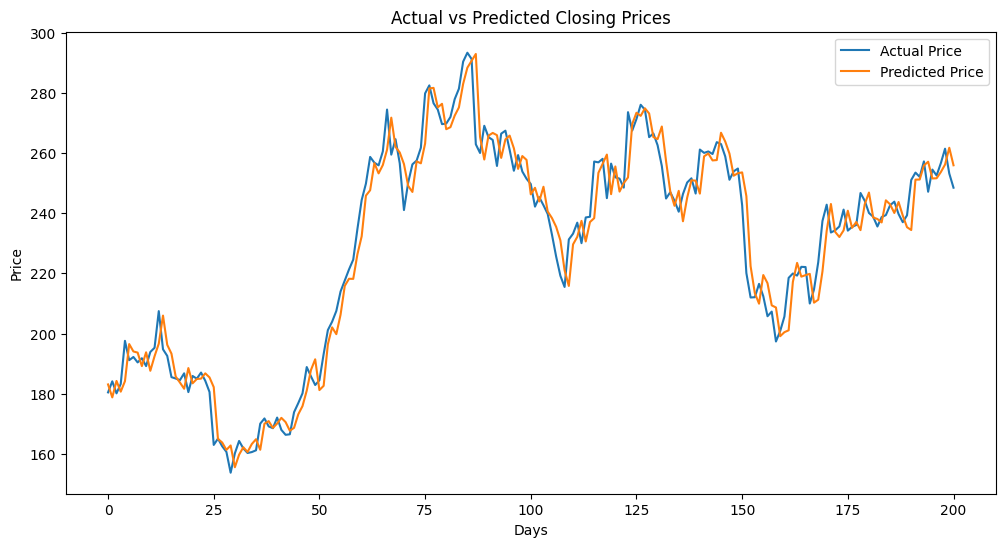

In [30]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

Step 10: Predict Next Day Price

In [31]:
latest_data = X.iloc[-1].values.reshape(1, -1)

next_day_prediction = model.predict(latest_data)

print("Predicted Next Day Closing Price:", next_day_prediction[0])

Predicted Next Day Closing Price: 255.93122567924482
